# COGS 108 - NBA Game Predicition Analysis 

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [  ] YES - make available
* [X] NO - keep private

## Link to video
https://link.to.your.publicly.viewable.video

## Abstract

This project investigates which categories of features best predict whether NBA betting favorites cover the point spread, a task fundamentally harder than simple win/loss prediction because the spread already prices in the expected margin. Using NBA regular-season games from 2010 to 2024, we construct three feature sets: (1) intra-game quarter-by-quarter scoring patterns, (2) team-aggregated box-score statistics such as shooting efficiency and turnovers, and (3) a combined set merging both. We train and compare Logistic Regression, Random Forest, and XGBoost classifiers on each feature set, evaluating them with classification accuracy. Our results show that Logistic Regression trained on the combined feature set achieved the highest test accuracy of 90.0%, indicating that quarter-by-quarter scoring patterns and box-score efficiency metrics provide complementary predictive information. Although box-score features alone were nearly as strong, the combined feature set performed best overall, suggesting that both overall team performance and intra-game scoring structure contribute meaningfully to predicting whether favorites cover the spread

## Authors

Team list and credits:
- Sanjith Shanmugavel - Software, Experimental Investigation, Analysis, Writing
- Asher King - Software, Writing, Background Research, Conceptualization
- Jessica Lu - Software, Writing, Project Administration, Methodology
- Abby Choi - Software, Writing, Review & Editing, Analysis
- Woojin Lee - Software, Writing, Background Research, Project Administration

## Research Question

Among quarter-by-quarter scoring patterns, team-aggregated player performance metrics (such as shooting efficiency, rebounding, turnovers, and plus-minus), and the combination of both, which set of features provides the strongest predictive power for whether NBA betting favorites cover the point spread?

Using publicly available NBA data, we will train and evaluate machine learning classification models on three distinct feature sets: intra-game scoring patterns found from quarter-by-quarter point distributions, team-aggregated player box score stats, like shooting percentages and plus-minus, and finally a combined feature set merging both sets. Our dependent variable is whether the betting favorite covered the spread, and our evaluation metric is classification accuracy. Our unit of analysis is a single NBA game.

## Background and Prior Work

The application of machine learning to NBA game prediction has been a commonly explored area of research. The models these researchers create typically achieve win/loss prediction accuracies in the 65–70% range. A comprehensive systematic review by Agyei-Boakye et al. (2024) looked at dozens of studies applying machine learning to sports betting and found that the most common approaches include Logistic Regression, Random Forest, SVMs, XGBoost, and neural networks. Random Forest and XGBoost were frequently among the top performers for NBA prediction tasks.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) For instance, Lin et al. (2014) used box score statistics from NBA games between 1991 and 1998 and achieved 65.15% accuracy with Random Forest, while Cao (2012) reached 69.67% accuracy with a Simple Logistics Classifier.<a name="cite_ref-1b"></a>[<sup>1</sup>](#cite_note-1) However, these studies focus on predicting who the outright winner is rather than spread coverage, which is a fundamentally much harder task because the spread already accounts for the expected margin of victory.


An underexplored question in this literature is the relative predictive value of different feature categories. Most existing models rely on either team-level statistics or pre-game ratings. He and Choi (2025) used a model trained on team-level offensive and defensive features from three NBA seasons and found that shooting efficiency variables were the most important predictors of game outcomes.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) On the other hand, people have also explored using player-level data as a predictor. One analysis comparing team statistics to aggregated player performance found that player-level stats yielded only 58.66% accuracy compared to a stronger performance from team-level features.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) This suggests that while player-level stats do have some meaningful predictive power, team-level features might be more useful.


What remains basically completely unexamined in the literature is how intra-game scoring patterns, specifically, quarter-by-quarter point distributions, compare to the usual box score metrics as predictive features for spread coverage. Quarter-by-quarter data captures small dynamics that final scores can't show, such as comeback patterns and dominant first halves. Our project directly addresses this gap by systematically comparing three feature sets: scoring patterns alone, player-derived box score stats alone, and the fusion of both. We want to test not just whether these features predict outcomes, but whether they contain information that the betting market has failed to fully incorporate.

<a name="cite_note-1"></a>1. Agyei-Boakye, Samuel, et al. "A Systematic Review of Machine Learning in Sports Betting: Techniques, Challenges, and Future Directions." arXiv, 2024, arxiv.org/abs/2410.21484.


<a name="cite_note-2"></a>2. He, Guangsen, and Hyun Soo Choi. "Stacked Ensemble Model for NBA Game Outcome Prediction Analysis." Scientific Reports, www.nature.com/articles/s41598-025-13657-1.

<a name="cite_note-3"></a>3. Cheng, Bryan, et al. "Predicting the Betting Line in NBA Games." 2013, cs229.stanford.edu/proj2013/ChengDadeLipmanMills-PredictingTheBettingLineInNBAGames.pdf.

# Hypothesis


We hypothesize that the combined feature set where we merge quarter-by-quarter scoring patterns with team-aggregated player box score statistics will achieve a higher classification accuracy for predicting spread coverage than either feature set alone. We also predict that all three feature sets will outperform the 50% random baseline.

More specifically, the player box score feature set will likely be the strongest individual predictor. This hypothesis is supported by the fact that prior work has consistently identified shooting efficiency as the most important predictive feature for NBA outcomes. We expect the quarter-by-quarter scoring feature set to provide a slightly weaker but certainly not a trivial amount of predictive power on its own, since intra-game scoring distributions capture game dynamics like momentum shifts and comeback patterns that aggregated stats miss. We hypothesize that the combined model should benefit from the complementary information.

## Data

### Data overview

We use two primary datasets: historical NBA betting lines with game scores (for point spreads and quarter-by-quarter scoring), and (2) NBA game statistics from official-style box score/team totals tables (for team performance features made from player contributions and/or team totals).

- Dataset 1
  - Dataset Name: NBA Betting Data (October 2007 to June 2024)
  - Link to the dataset: https://www.kaggle.com/datasets/cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024
  - Number of observations: 33316
  - Number of variables: 57
  - Description of the variables most relevant to this project:
    - Closing point spread in points, indicating the expected margin of victory for the favorite
    - Game scores, and quarter-by-quarter scoring fields for both teams
    - A way to identify the favorite and underdog, or equivalently to identify which team is “laying” points
  - Shortcomings for this project:
    - Betting-line fields may be missing for some games
    - Pushes (favorite wins by exactly the spread) need an explicit handling decision (drop, label separately, or treat as non-cover)
    - Quarter scoring may be missing for some eras, and OT fields (if present) require careful normalization

- Dataset 2
  - Dataset Name: NBA-Data-2010-2024 (Game totals and/or player box scores)
  - Link to the dataset: https://github.com/NocturneBear/NBA-Data-2010-2024
  - Number of observations: 23118
  - Number of variables: 27
  - Description of the variables most relevant to this project:
    - Team-level box score totals per game (FGM/FGA/FG%, 3PT, FT, OREB/DREB/REB, AST, TOV, STL, BLK, PF, PTS, PLUS_MINUS, etc.)
    - If using player-level box scores, we can aggregate to team-level by game to compute team features consistent with our research question
  - Shortcomings for this project:
    - This dataset does not include betting lines, so it must be merged to Dataset 1
    - Team identifiers may differ in format across datasets (full names vs abbreviations vs tricodes), requiring normalization
    - Some seasons may have missing or inconsistent rows for special cases (neutral sites, rescheduled games)

Combining datasets

We will merge the betting dataset (Dataset 1) with the NBA stats dataset (Dataset 2) at the game level. Our preferred join keys are:
- game date (normalized to local date, no time component)
- team identities (home/away team, or favorite/underdog mapped to team abbreviations)


In [15]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    # Team totals (one row per team per game, regular season)
    {
        "url": "https://raw.githubusercontent.com/NocturneBear/NBA-Data-2010-2024/main/regular_season_totals_2010_2024.csv",
        "filename": "regular_season_totals_2010_2024.csv",
    },

    # Player box scores (large, split into 3 parts)
    {
        "url": "https://raw.githubusercontent.com/NocturneBear/NBA-Data-2010-2024/main/regular_season_box_scores_2010_2024_part_1.csv",
        "filename": "regular_season_box_scores_2010_2024_part_1.csv",
    },
    {
        "url": "https://raw.githubusercontent.com/NocturneBear/NBA-Data-2010-2024/main/regular_season_box_scores_2010_2024_part_2.csv",
        "filename": "regular_season_box_scores_2010_2024_part_2.csv",
    },
    {
        "url": "https://raw.githubusercontent.com/NocturneBear/NBA-Data-2010-2024/main/regular_season_box_scores_2010_2024_part_3.csv",
        "filename": "regular_season_box_scores_2010_2024_part_3.csv",
    },
]

get_data.get_raw(datafiles, destination_directory="data/00-raw/")

Overall Download Progress:  25%|██▌       | 1/4 [00:12<00:38, 12.75s/it]

Successfully downloaded: regular_season_totals_2010_2024.csv


Overall Download Progress:  50%|█████     | 2/4 [00:29<00:30, 15.00s/it]

Successfully downloaded: regular_season_box_scores_2010_2024_part_1.csv


Overall Download Progress:  75%|███████▌  | 3/4 [00:31<00:09,  9.27s/it]

Successfully downloaded: regular_season_box_scores_2010_2024_part_2.csv


Overall Download Progress: 100%|██████████| 4/4 [00:35<00:00,  8.93s/it]

Successfully downloaded: regular_season_box_scores_2010_2024_part_3.csv


In [ ]:
# Download and save the raw datasets used in this project.
from kaggle.api.kaggle_api_extended import KaggleApi
from pathlib import Path

RAW = Path("data/00-raw")
RAW.mkdir(parents=True, exist_ok=True)

api = KaggleApi()
api.authenticate()

api.dataset_download_files(
    "cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024",
    path=str(RAW),
    unzip=True
)



Dataset URL: https://www.kaggle.com/datasets/cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024


### Dataset 1: NBA betting lines and scoring outcomes (2007–2024)

This dataset contains historical NBA betting and game outcome information at the game level, including point spreads and final scores. Each row corresponds to a single NBA game, which makes it the primary source for defining our dependent variable, whether the betting favorite covered the point spread.
For our project, this dataset supports two critical components. First, it provides the spread needed to compute the target label. A favorite is considered to have covered when its margin of victory exceeds the absolute value of the spread. Second, this dataset supplies the quarter-by-quarter scoring fields, which we use to build intra-game scoring pattern features such as quarter margins, first-half margin, second-half margin, and third-quarter swing. These features capture within-game dynamics that final scores alone can obscure.

Key variables and units  
- Point spread is measured in points and indicates the expected margin of victory for the favorite.  
- Points scored.  
- Point differentials.  
- The target label (`favorite_cover`) is a binary indicator derived from spread and final margin.

Main concerns and limitations    
- This dataset does not contain the detailed team performance statistics (shooting efficiency, rebounds, turnovers, plus-minus) needed for our team-metric feature set, so it must be merged with Dataset 2 using normalized team identifiers.


In [ ]:
# Load the box-score datasets and check shape, missingness, and basic validity.
import pandas as pd
from pathlib import Path

RAW = Path("data/00-raw")
INTERIM = Path("data/01-interim")
PROCESSED = Path("data/02-processed")

d1_files = sorted(RAW.glob("regular_season_*.csv"))

def clean_and_summarize(csv_path: Path):
    df = pd.read_csv(csv_path)

    print("\nFILE", csv_path.name)
    print("shape", df.shape)
    display(df.head())

    if "GAME_DATE" in df.columns:
        df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"], errors="coerce")

    missing = df.isna().mean().sort_values(ascending=False).head(15)
    display(missing)

    pct_cols = [c for c in ["FG_PCT", "FG3_PCT", "FT_PCT"] if c in df.columns]
    if pct_cols:
        bad_pct = df[pct_cols].apply(lambda s: (s < 0) | (s > 1)).any(axis=1)
        print("rows with suspicious pct", int(bad_pct.sum()))

    if "PTS" in df.columns:
        bad_pts = (df["PTS"] < 0) | (df["PTS"] > 200)
        print("rows with suspicious pts", int(bad_pts.sum()))

    key_candidates = ["GAME_ID", "TEAM_ID", "PLAYER_ID", "GAME_DATE"]
    keys = [c for c in key_candidates if c in df.columns]
    if keys:
        df_clean = df.dropna(subset=keys).copy()
    else:
        df_clean = df.dropna(how="all").copy()
    out_name = csv_path.stem.replace("regular_season_", "") + "_clean.csv"
    df_clean.to_csv(INTERIM / f"interim_{out_name}", index=False)
    df_clean.to_csv(PROCESSED / f"processed_{out_name}", index=False)

    return {
        "file": csv_path.name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "rows_after_clean": df_clean.shape[0],
        "cols_after_clean": df_clean.shape[1],
    }

summaries = [clean_and_summarize(p) for p in d1_files]
summary_df = pd.DataFrame(summaries)
display(summary_df)
for r in summaries:
    print(f"- {r['file']}  observations {r['rows']}  variables {r['cols']}")



FILE regular_season_box_scores_2010_2024_part_1.csv
shape (141493, 34)


,season_year,game_date,gameId,matchup,teamId,teamCity,teamName,teamTricode,teamSlug,personId,...,reboundsOffensive,reboundsDefensive,reboundsTotal,assists,steals,blocks,turnovers,foulsPersonal,points,plusMinusPoints
0,2010-11,2010-11-10,21000112,NJN @ CLE,1610612751,New Jersey,Nets,NJN,nets,693,...,0,0,0,0,0,0,0,0,0,-4
1,2010-11,2010-11-17,21000165,NJN @ UTA,1610612751,New Jersey,Nets,NJN,nets,693,...,0,0,0,0,0,0,0,0,0,0
2,2010-11,2010-11-27,21000237,NJN @ PHI,1610612751,New Jersey,Nets,NJN,nets,693,...,0,0,0,0,0,0,0,0,0,0
3,2010-11,2010-12-12,21000351,NJN vs. LAL,1610612751,New Jersey,Nets,NJN,nets,693,...,0,0,0,0,0,0,0,0,0,0
4,2010-11,2010-10-29,21000020,NJN vs. SAC,1610612751,New Jersey,Nets,NJN,nets,693,...,0,1,1,1,0,0,1,1,2,6


jerseyNum                 1.000000
comment                   0.833956
position                  0.606624
minutes                   0.166044
season_year               0.000000
reboundsOffensive         0.000000
freeThrowsMade            0.000000
freeThrowsAttempted       0.000000
freeThrowsPercentage      0.000000
reboundsDefensive         0.000000
threePointersAttempted    0.000000
reboundsTotal             0.000000
assists                   0.000000
steals                    0.000000
blocks                    0.000000
dtype: float64


FILE regular_season_box_scores_2010_2024_part_2.csv
shape (141493, 34)


,season_year,game_date,gameId,matchup,teamId,teamCity,teamName,teamTricode,teamSlug,personId,...,reboundsOffensive,reboundsDefensive,reboundsTotal,assists,steals,blocks,turnovers,foulsPersonal,points,plusMinusPoints
0,2010-11,2010-12-11,21000347,HOU vs. CLE,1610612745,Houston,Rockets,HOU,rockets,2449,...,6,8,14,1,1,0,4,3,14,10
1,2010-11,2010-11-19,21000173,HOU @ TOR,1610612745,Houston,Rockets,HOU,rockets,2449,...,1,4,5,3,1,1,2,3,19,0
2,2011-12,2012-03-18,21100667,HOU @ PHX,1610612745,Houston,Rockets,HOU,rockets,2449,...,3,4,7,3,0,0,0,2,18,-6
3,2010-11,2010-12-22,21000429,HOU @ LAC,1610612745,Houston,Rockets,HOU,rockets,2449,...,1,2,3,2,2,2,4,5,22,-3
4,2010-11,2011-02-22,21000840,HOU @ DET,1610612745,Houston,Rockets,HOU,rockets,2449,...,3,6,9,1,1,2,3,3,8,1


...

,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG
0,2022-23,1610612744,GSW,Golden State Warriors,22201230,2023-04-09T00:00:00,GSW @ POR,W,48.0,58,...,1,1578,55,512,457,678,2455,3,1,1.0
1,2020-21,1610612749,MIL,Milwaukee Bucks,22000051,2020-12-29T00:00:00,MIL @ MIA,W,48.0,51,...,146,1636,33,1830,1361,1552,1220,14,7,1.0
2,2013-14,1610612751,BKN,Brooklyn Nets,21300359,2013-12-16T00:00:00,BKN vs. PHI,W,48.0,47,...,22,2280,406,1979,1,1004,453,19,12,1.0
3,2013-14,1610612757,POR,Portland Trail Blazers,21300347,2013-12-14T00:00:00,POR @ PHI,W,48.0,52,...,2,2065,628,204,1269,272,2190,4,15,1.0
4,2018-19,1610612745,HOU,Houston Rockets,21801200,2019-04-07T00:00:00,HOU vs. PHX,W,48.0,53,...,84,176,149,917,1,244,1725,4,20,1.0


AVAILABLE_FLAG    0.13369
PLUS_MINUS        0.00000
W_RANK            0.00000
L_RANK            0.00000
W_PCT_RANK        0.00000
MIN_RANK          0.00000
FGM_RANK          0.00000
FGA_RANK          0.00000
FG_PCT_RANK       0.00000
FG3M_RANK         0.00000
FG3A_RANK         0.00000
FG3_PCT_RANK      0.00000
FTM_RANK          0.00000
FTA_RANK          0.00000
FT_PCT_RANK       0.00000
dtype: float64

rows with suspicious pct 0
rows with suspicious pts 0


,file,rows,cols,rows_after_clean,cols_after_clean
0,regular_season_box_scores_2010_2024_part_1.csv,141493,34,141493,34
1,regular_season_box_scores_2010_2024_part_2.csv,141493,34,141493,34
2,regular_season_box_scores_2010_2024_part_3.csv,141492,34,141492,34
3,regular_season_totals_2010_2024.csv,33316,57,33316,57


- regular_season_box_scores_2010_2024_part_1.csv  observations 141493  variables 34
- regular_season_box_scores_2010_2024_part_2.csv  observations 141493  variables 34
- regular_season_box_scores_2010_2024_part_3.csv  observations 141492  variables 34
- regular_season_totals_2010_2024.csv  observations 33316  variables 57


### Dataset 2: NBA team performance statistics from box scores and game totals (2010–2024)

This dataset comes from the NBA-Data-2010-2024 repository and includes NBA statistics tables from official-style box scores and team game totals. The repository provides both player box score tables and team game totals tables. The published schema includes standard basketball counting stats (field goals, three-pointers, free throws, rebounds, assists, turnovers, steals, blocks, fouls, points) and efficiency percentages, as well as plus-minus.

For our project, we will primarily use the team game totals tables because they already represent team-aggregated performance per game and directly match our planned feature set (shooting efficiency, rebounding, turnovers, and plus-minus). If needed for additional engineered features, we can also derive team-level features by aggregating the player-level box score table by (gameId, teamId).

Key variables and units
- Points, rebounds, assists, turnovers, etc. are counts per game.
- FG_PCT, FG3_PCT, FT_PCT are proportions in [0, 1]
- PLUS_MINUS (point differential when the team/player is on the floor)

Main concerns and limitations
- There is no betting information here, so this dataset must be merged with Dataset 1.


In [ ]:
# Load the betting dataset and inspect missing values and numeric ranges.
import pandas as pd
from pathlib import Path

RAW = Path("data/00-raw")
INTERIM = Path("data/01-interim")
PROCESSED = Path("data/02-processed")

bet = pd.read_csv(RAW / "nba_2008-2025.csv")

bet.columns = bet.columns.str.strip()

print("shape", bet.shape)
display(bet.head())

missing = bet.isna().mean().sort_values(ascending=False)
display(missing.head(15))

num = bet.select_dtypes("number")
if not num.empty:
    display(num.describe().T[["min", "max"]].head(15))

bet_clean = bet.dropna(how='all').copy()

bet_clean.to_csv(INTERIM / "betting_interim.csv", index=False)
bet_clean.to_csv(PROCESSED / "betting_clean.csv", index=False)
print(f"observations {bet.shape[0]}  variables {bet.shape[1]}")


shape (23118, 27)


,season,date,regular,playoffs,away,home,score_away,score_home,q1_away,q2_away,...,ot_home,whos_favored,spread,total,moneyline_away,moneyline_home,h2_spread,h2_total,id_spread,id_total
0,2008,2007-10-30,True,False,por,sa,97,106,26,23,...,0,home,13.0,189.5,900.0,-1400.0,5.0,95.0,0.0,1
1,2008,2007-10-30,True,False,utah,gs,117,96,28,34,...,0,home,1.0,212.0,100.0,-120.0,3.0,105.5,0.0,1
2,2008,2007-10-30,True,False,hou,lal,95,93,16,27,...,0,away,5.0,199.0,-230.0,190.0,3.0,99.0,0.0,0
3,2008,2007-10-31,True,False,phi,tor,97,106,22,28,...,0,home,6.5,191.0,255.0,-305.0,2.0,96.5,1.0,1
4,2008,2007-10-31,True,False,wsh,ind,110,119,23,22,...,16,away,1.5,203.5,-125.0,105.0,1.0,105.0,0.0,1


h2_total          0.142789
moneyline_home    0.142659
moneyline_away    0.142659
h2_spread         0.142573
id_spread         0.000130
spread            0.000130
season            0.000000
q2_home           0.000000
total             0.000000
whos_favored      0.000000
ot_home           0.000000
q4_home           0.000000
q3_home           0.000000
q1_home           0.000000
date              0.000000
dtype: float64

,min,max
season,2008.0,2025.0
score_away,54.0,176.0
score_home,59.0,175.0
q1_away,7.0,55.0
q2_away,4.0,49.0
q3_away,5.0,52.0
q4_away,5.0,51.0
ot_away,0.0,44.0
q1_home,5.0,55.0
q2_home,5.0,51.0


observations 23118  variables 27


## Results

### Exploratory Data Analysis

In our EDA, we will explore the two processed datasets to evaluate the individual and combined predictive power of quarter-by-quarter scoring and team box score metrics. Our EDA is divided into 3 main objectives:
1. Exploring the Target Variable: Defining and exploring our dependent variable: whether the betting favorite covered the spread.
2. Feature Set 1 Analysis (Intra-game Scoring): Analyzing how quarter-by-quarter point differentials relate to spread coverage.
3. Feature Set 2 Analysis (Team Box Scores): Analyzing how traditional efficiency metrics like FG% and Rebounds correlate with our target variable.

We start our EDA process by loading our clean data from the data/02-processed directory.

In [ ]:
# Load the cleaned datasets for exploratory analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.titlesize': 16, 'axes.labelsize': 12, 'axes.titlesize': 14})

betting_df = pd.read_csv("data/02-processed/betting_clean.csv")
totals_df = pd.read_csv("data/02-processed/processed_totals_2010_2024_clean.csv")

# Standardize date formats
if "GAME_DATE" in betting_df.columns:
    betting_df["GAME_DATE"] = pd.to_datetime(betting_df["GAME_DATE"])
if "GAME_DATE" in totals_df.columns:
    totals_df["GAME_DATE"] = pd.to_datetime(totals_df["GAME_DATE"])

print(f"Betting Data Shape: {betting_df.shape}")
print(f"Totals Data Shape: {totals_df.shape}")

Betting Data Shape: (23118, 27)
Totals Data Shape: (33316, 57)


#### Section 1: Exploring the Target Variable

Before we analyze our features, we should accurate define our target variable. The target variable for our study is favorite_cover. A betting favorite covers the spread if their final margin of victory is strictly greater than the point spread. If the margin equals the spread, it is considered a push or a tie, which we will drop for the sake of our binary classification. 

In this section, we will calculate the favorite's actual margin of victory and compare it to the spread line to create our binary label.

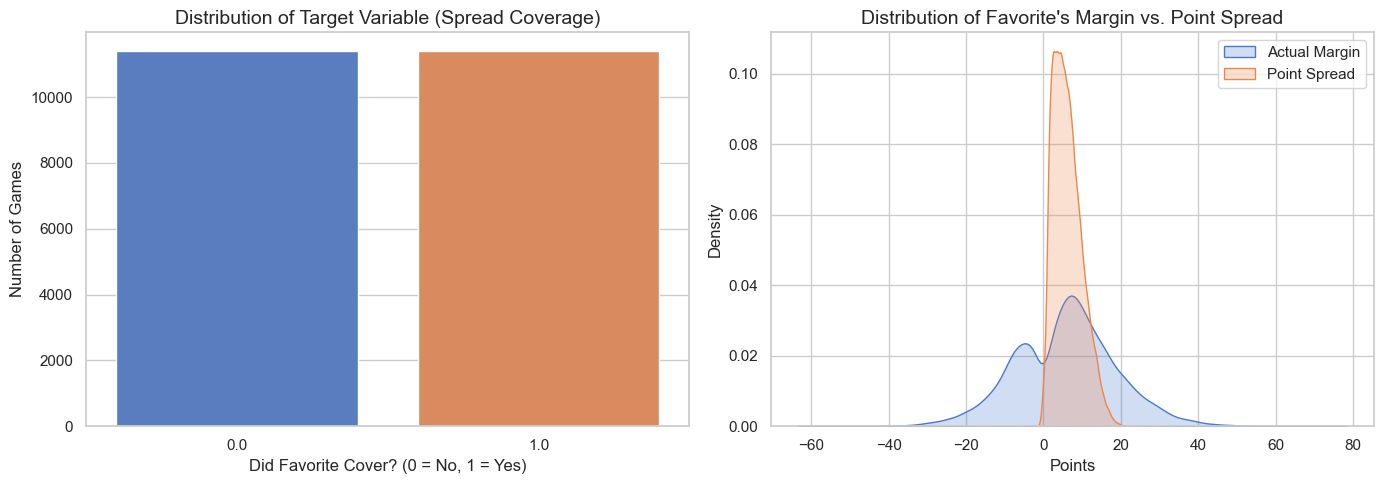

In [17]:
# 1. Calculate actual margin of victory for favored team

def calculate_margin(row):
    if pd.isna(row['whos_favored']) or pd.isna(row['spread']):
        return np.nan
    if row['whos_favored'] == 'home':
        return row['score_home'] - row['score_away']
    elif row['whos_favored'] == 'away':
        return row['score_away'] - row['score_home']
    return np.nan

# Apply function to create the margin column
betting_df['favorite_margin'] = betting_df.apply(calculate_margin, axis=1)

# 2. Determine if favorite covered (1), failed to cover (0), or tied (NaN)
conditions = [
    betting_df['favorite_margin'] > betting_df['spread'],  # Cover
    betting_df['favorite_margin'] < betting_df['spread']   # No Cover
]
choices = [1, 0]
betting_df['favorite_cover'] = np.select(conditions, choices, default=np.nan)

# 3. Drop ties
betting_df = betting_df.dropna(subset=['favorite_cover']).copy()

# Visualization 
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class balance (Countplot)
sns.countplot(data=betting_df, x='favorite_cover', ax=ax[0])
ax[0].set_title("Distribution of Target Variable (Spread Coverage)")
ax[0].set_xlabel("Did Favorite Cover? (0 = No, 1 = Yes)")
ax[0].set_ylabel("Number of Games")

# Plot 2: Actual Margin vs Spread (KDE Plot)
sns.kdeplot(data=betting_df, x='favorite_margin', label='Actual Margin', fill=True, ax=ax[1])
sns.kdeplot(data=betting_df, x='spread', label='Point Spread', fill=True, ax=ax[1])
ax[1].set_title("Distribution of Favorite's Margin vs. Point Spread")
ax[1].set_xlabel("Points")
ax[1].set_ylabel("Density")
ax[1].legend()

plt.tight_layout()
plt.show()

#### Section 2 of EDA: Intra-game Scoring and Spread Coverage

Exploring whether the favorite's first-half scoring margin meaningfully differs between games where they cover the spread and games where they do not in order to evaluate early-game performance as a significant predictor of spread coverage.

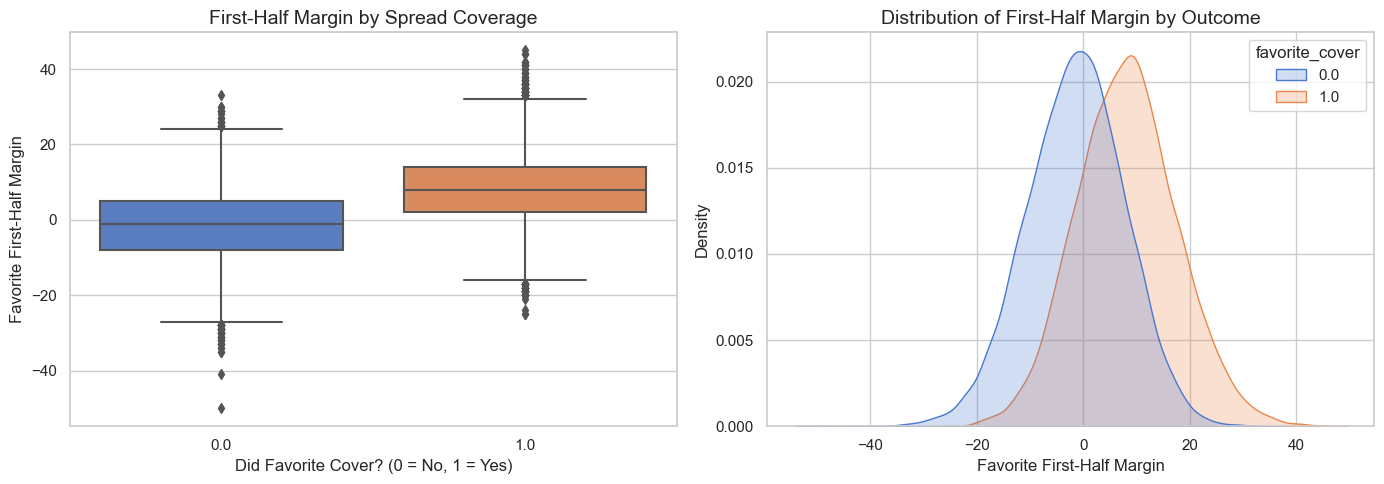

In [18]:
# 1. Calculate first-quarter and second-quarter differentials (favorite perspective)

def fav_quarter_diff(row, quarter):
    if row['whos_favored'] == 'home':
        return row[f'q{quarter}_home'] - row[f'q{quarter}_away']
    elif row['whos_favored'] == 'away':
        return row[f'q{quarter}_away'] - row[f'q{quarter}_home']
    return np.nan

betting_df['fav_q1_diff'] = betting_df.apply(lambda row: fav_quarter_diff(row, 1), axis=1)
betting_df['fav_q2_diff'] = betting_df.apply(lambda row: fav_quarter_diff(row, 2), axis=1)

# 2. Compute first-half margin
betting_df['fav_first_half_margin'] = (
betting_df['fav_q1_diff'] + betting_df['fav_q2_diff']
)

# 3. Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Boxplot by coverage outcome
sns.boxplot(data=betting_df, x='favorite_cover', y='fav_first_half_margin', ax=ax[0])
ax[0].set_title("First-Half Margin by Spread Coverage")
ax[0].set_xlabel("Did Favorite Cover? (0 = No, 1 = Yes)")
ax[0].set_ylabel("Favorite First-Half Margin")

# Plot 2: KDE comparison
sns.kdeplot(data=betting_df, x='fav_first_half_margin', hue='favorite_cover', fill=True, ax=ax[1])
ax[1].set_title("Distribution of First-Half Margin by Outcome")
ax[1].set_xlabel("Favorite First-Half Margin")
ax[1].set_ylabel("Density")

plt.tight_layout()
plt.show()


### Section 3 of EDA: Team Box Score Metrics and Spread Coverage

In this section we explore the relationship between traditional team-level performance metrics like field-goal percentage (FG_PCT), three-point percentage (FG3_PCT), total rebounds (REB), and plus-minus (PLUS_MINUS). Our target variable is favorite_cover. We examine distributions and statistical significance to determine whether these features carry meaningful predictive signal for spread coverage.

In [19]:
# Merging betting data with team totals

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.titlesize': 16, 'axes.labelsize': 12,
                     'axes.titlesize': 14})

Path("results").mkdir(exist_ok=True)

totals_df  = pd.read_csv("data/02-processed/processed_totals_2010_2024_clean.csv")

# Normalize dates
betting_df['date'] = pd.to_datetime(betting_df['date'])
totals_df['GAME_DATE']  = pd.to_datetime(totals_df['GAME_DATE'])

# Team-abbreviation map
team_map = {
    'atl': 'ATL', 'bos': 'BOS', 'bkn': 'BKN', 'brk': 'BKN', 'njn': 'BKN',
    'cha': 'CHA', 'cho': 'CHA', 'chi': 'CHI', 'cle': 'CLE', 'dal': 'DAL',
    'den': 'DEN', 'det': 'DET', 'gs':  'GSW', 'gsw': 'GSW', 'hou': 'HOU',
    'ind': 'IND', 'lac': 'LAC', 'lal': 'LAL', 'mem': 'MEM', 'mia': 'MIA',
    'mil': 'MIL', 'min': 'MIN', 'no':  'NOP', 'nop': 'NOP', 'noh': 'NOP',
    'nyk': 'NYK', 'okc': 'OKC', 'orl': 'ORL', 'phi': 'PHI', 'phx': 'PHX',
    'por': 'POR', 'sa':  'SAS', 'sas': 'SAS', 'sac': 'SAC', 'tor': 'TOR',
    'uta': 'UTA', 'utah': 'UTA', 'was': 'WAS', 'wsh': 'WAS',
}

betting_df['home_tri'] = betting_df['home'].map(team_map)
betting_df['away_tri'] = betting_df['away'].map(team_map)

betting_df['fav_tri'] = np.where(
    betting_df['whos_favored'] == 'home',
    betting_df['home_tri'],
    betting_df['away_tri']
)
betting_df['dog_tri'] = np.where(
    betting_df['whos_favored'] == 'home',
    betting_df['away_tri'],
    betting_df['home_tri']
)

# Merge favorite team stats
fav_stats = totals_df.rename(columns={'GAME_DATE': 'date',
                                       'TEAM_ABBREVIATION': 'fav_tri'})
fav_cols = ['FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'TOV', 'STL', 'BLK',
            'AST', 'PLUS_MINUS', 'PTS']
fav_stats = fav_stats[['date', 'fav_tri'] + fav_cols]
fav_stats.columns = ['date', 'fav_tri'] + ['fav_' + c for c in fav_cols]

merged = betting_df.merge(fav_stats, on=['date', 'fav_tri'], how='inner')

# Merge underdog team stats
dog_stats = totals_df.rename(columns={'GAME_DATE': 'date',
                                       'TEAM_ABBREVIATION': 'dog_tri'})
dog_stats = dog_stats[['date', 'dog_tri'] + fav_cols]
dog_stats.columns = ['date', 'dog_tri'] + ['dog_' + c for c in fav_cols]

merged = merged.merge(dog_stats, on=['date', 'dog_tri'], how='inner')

# Create differential features
for stat in ['FG_PCT', 'FG3_PCT', 'REB', 'TOV', 'AST', 'PLUS_MINUS']:
    merged[f'diff_{stat}'] = merged[f'fav_{stat}'] - merged[f'dog_{stat}']

# Rebuild quarter-level features on the merged set
def fav_q_diff(row, q):
    if row['whos_favored'] == 'home':
        return row[f'q{q}_home'] - row[f'q{q}_away']
    elif row['whos_favored'] == 'away':
        return row[f'q{q}_away'] - row[f'q{q}_home']
    return np.nan

for q in [1, 2, 3, 4]:
    merged[f'fav_q{q}_diff'] = merged.apply(lambda r: fav_q_diff(r, q), axis=1)

merged['fav_first_half_margin']  = merged['fav_q1_diff'] + merged['fav_q2_diff']
merged['fav_second_half_margin'] = merged['fav_q3_diff'] + merged['fav_q4_diff']
merged['fav_q3_swing']           = merged['fav_q3_diff'] - merged['fav_q2_diff']

print(f"Merged dataset shape: {merged.shape}")
print(f"\nCover distribution:\n{merged['favorite_cover'].value_counts()}")
merged.to_csv("data/02-processed/merged_betting_totals.csv", index=False)

Merged dataset shape: (14950, 66)

Cover distribution:
0.0    7526
1.0    7424
Name: favorite_cover, dtype: int64


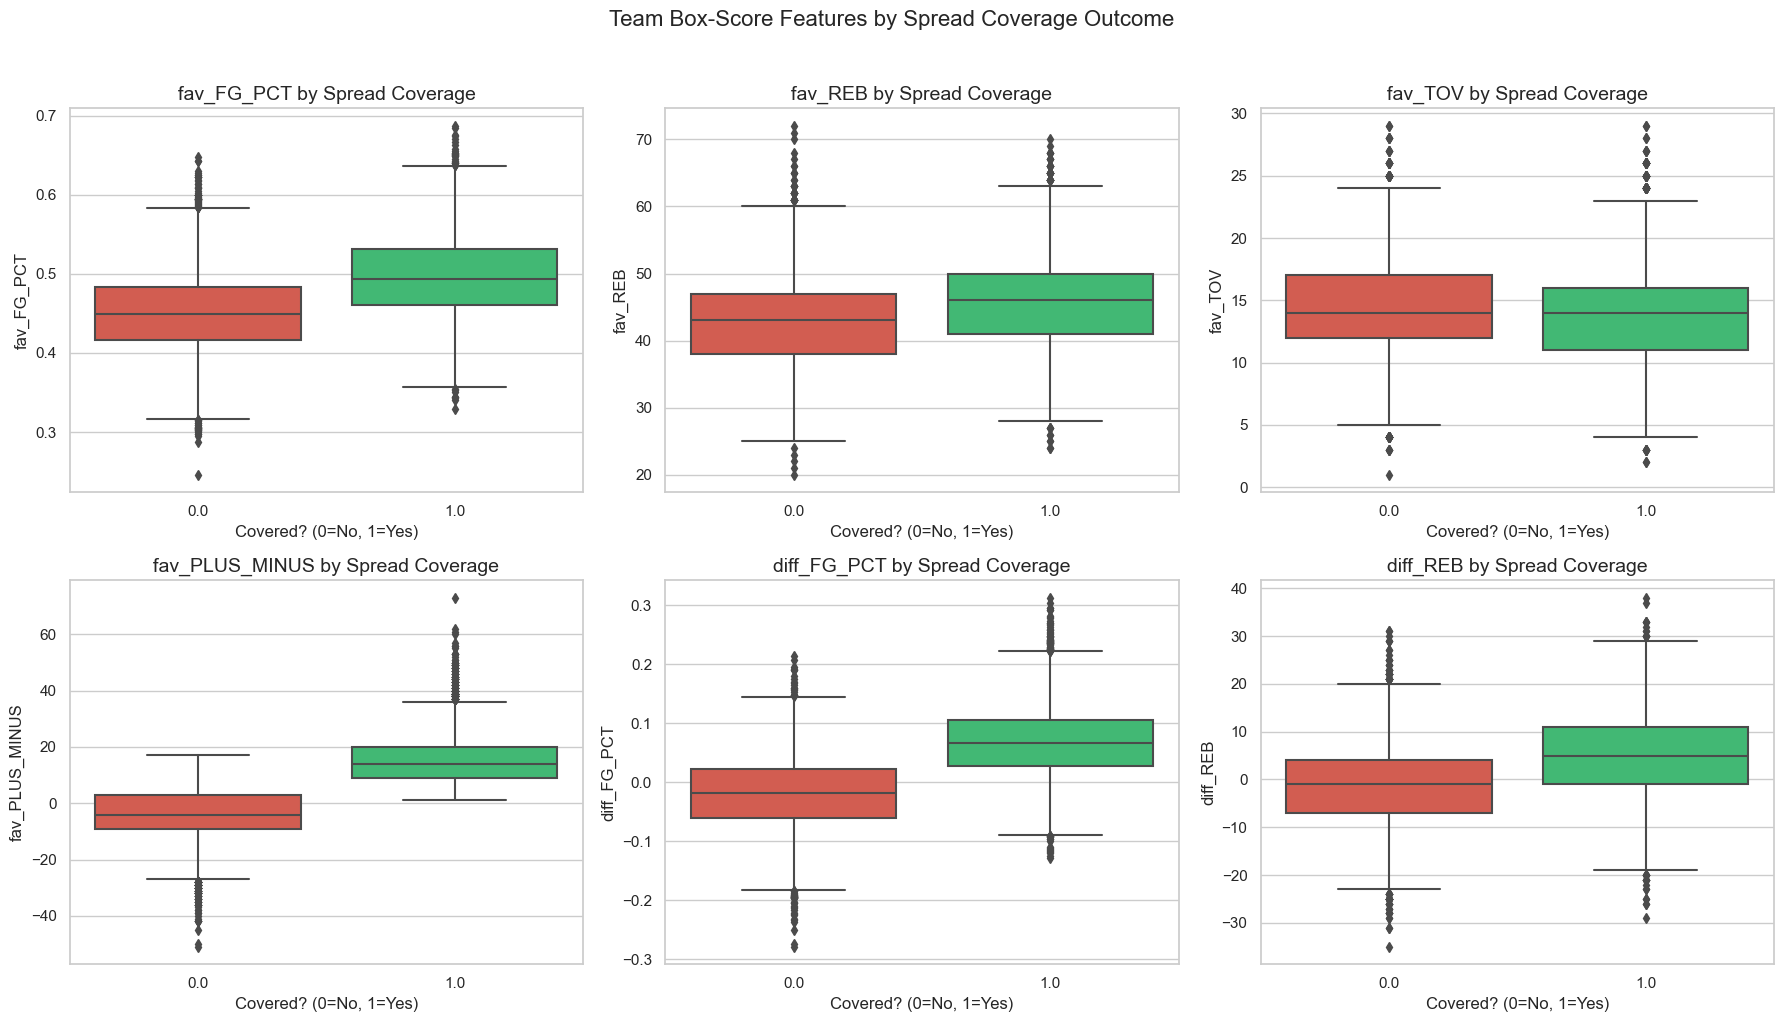

In [20]:
# Visualizing box-score features by spread-coverage outcome

key_features = ['fav_FG_PCT', 'fav_REB', 'fav_TOV', 'fav_PLUS_MINUS',
                'diff_FG_PCT', 'diff_REB']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(data=merged, x='favorite_cover', y=feat, ax=axes[i],
                palette={0: '#e74c3c', 1: '#2ecc71'})
    axes[i].set_title(f"{feat} by Spread Coverage")
    axes[i].set_xlabel("Covered? (0=No, 1=Yes)")

plt.suptitle("Team Box-Score Features by Spread Coverage Outcome",
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("results/eda_boxscore_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

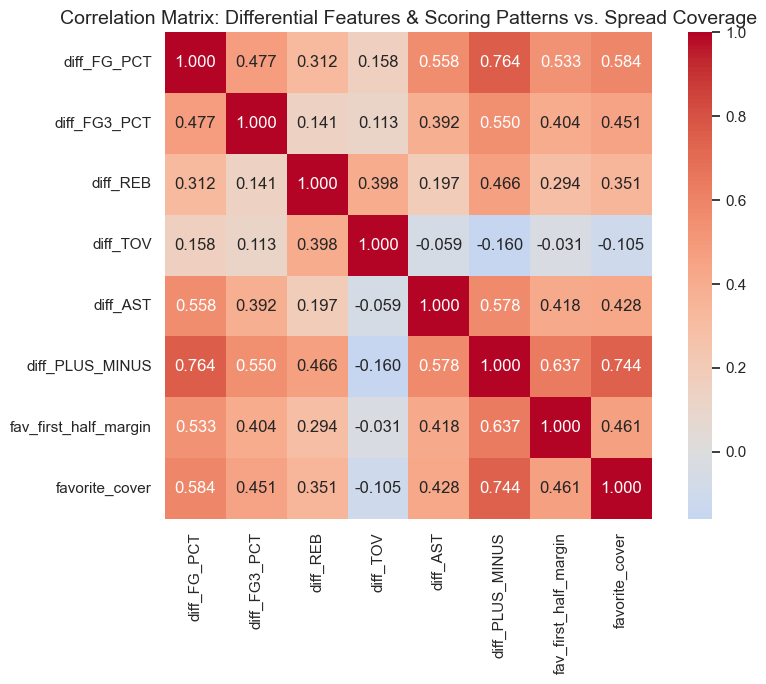

In [21]:
# Correlation heatmap of differential features with target

corr_cols = ['diff_FG_PCT', 'diff_FG3_PCT', 'diff_REB', 'diff_TOV',
             'diff_AST', 'diff_PLUS_MINUS', 'fav_first_half_margin',
             'favorite_cover']
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix: Differential Features & Scoring Patterns vs. Spread Coverage")
plt.tight_layout()
plt.savefig("results/eda_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

#### Interpretation:

The correlation heatmap reveals that `diff_PLUS_MINUS` (the favorite's plus-minus advantage over the underdog) has the strongest linear association with spread coverage, followed by `diff_FG_PCT`. Rebound and turnover differentials show weaker but non-trivial correlations. The first-half margin from our quarter-by-quarter features also correlates with the target, though not as strongly as the box-score differentials. This aligns with prior work identifying shooting efficiency as the most important predictor of NBA outcomes (He & Choi, 2025).

### Statistical Analysis of Feature–Outcome Relationships

To move beyond visual inspection, we perform formal statistical tests comparing feature distributions between games where the favorite covered and games where they did not. We use independent-samples Welch's t-tests for continuous features and report Cohen's d for effect size.

In [22]:
# Welch's t-tests and effect sizes

from scipy.stats import ttest_ind, pointbiserialr

cover   = merged[merged['favorite_cover'] == 1]
nocover = merged[merged['favorite_cover'] == 0]

test_features = [
    'fav_FG_PCT', 'fav_FG3_PCT', 'fav_REB', 'fav_TOV', 'fav_PLUS_MINUS',
    'diff_FG_PCT', 'diff_REB', 'diff_TOV', 'diff_PLUS_MINUS',
    'fav_first_half_margin', 'fav_second_half_margin', 'fav_q3_swing'
]

results = []
for feat in test_features:
    c_vals  = cover[feat].dropna()
    nc_vals = nocover[feat].dropna()
    t_stat, p_val = ttest_ind(c_vals, nc_vals, equal_var=False)
    # Cohen's d
    pooled_std = np.sqrt((c_vals.std()**2 + nc_vals.std()**2) / 2)
    d = (c_vals.mean() - nc_vals.mean()) / pooled_std if pooled_std > 0 else 0
    # Point-biserial correlation
    combined = merged[[feat, 'favorite_cover']].dropna()
    r_pb, p_pb = pointbiserialr(combined['favorite_cover'], combined[feat])
    results.append({
        'Feature': feat,
        'Mean (Cover)': round(c_vals.mean(), 4),
        'Mean (No Cover)': round(nc_vals.mean(), 4),
        't-statistic': round(t_stat, 3),
        'p-value': f"{p_val:.2e}",
        "Cohen's d": round(d, 3),
        'r_pb': round(r_pb, 4),
    })

stat_df = pd.DataFrame(results)
print("Statistical Tests: Cover vs. No-Cover Groups")
print("=" * 90)
display(stat_df)
stat_df.to_csv("results/statistical_tests.csv", index=False)

Statistical Tests: Cover vs. No-Cover Groups


,Feature,Mean (Cover),Mean (No Cover),t-statistic,p-value,Cohen's d,r_pb
0,fav_FG_PCT,0.4957,0.4502,54.813,0.00e+00,0.897,0.4091
1,fav_FG3_PCT,0.3976,0.3343,42.389,0.00e+00,0.694,0.3277
2,fav_REB,45.8607,42.9240,27.791,8.80e-166,0.455,0.2216
3,fav_TOV,13.7946,14.2673,-7.495,6.99e-14,-0.123,-0.0612
4,fav_PLUS_MINUS,15.5004,-4.0594,136.291,0.00e+00,2.229,0.7443
5,diff_FG_PCT,0.0671,-0.0196,87.895,0.00e+00,1.438,0.5837
6,diff_REB,4.9476,-1.4050,45.793,0.00e+00,0.749,0.3507
7,diff_TOV,-0.9609,0.1015,-12.888,8.37e-38,-0.211,-0.1048
8,diff_PLUS_MINUS,31.0008,-8.1188,136.291,0.00e+00,2.229,0.7443
9,fav_first_half_margin,8.2290,-1.4934,63.556,0.00e+00,1.040,0.4613


**Interpretation of Statistical Tests:**

The statistical tests reinforce the patterns from the earlier visualizations and correlation analysis. The strongest differences between cover and no-cover games come from plus-minus related variables. In particular, `fav_PLUS_MINUS` and `diff_PLUS_MINUS` have by far the largest test statistics and effect sizes, which suggests that overall point-margin dominance is tightly associated with whether the favorite covers the spread. Shooting efficiency is also highly informative, with `fav_FG_PCT`, `fav_FG3_PCT`, and especially `diff_FG_PCT` showing very large differences between the two groups.

Rebounding and turnover variables are also statistically significant, but their effect sizes are smaller. This suggests they appear to be secondary compared with shooting efficiency and plus-minus. Among the quarter-based features, both `fav_first_half_margin` and `fav_second_half_margin` show large and highly significant differences, indicating that favorites who cover tend to establish and maintain stronger scoring advantages throughout the game. By contrast, `fav_q3_swing` is statistically significant but has a much smaller effect size, so isolated momentum shifts seem less useful than broader half-level control.

Overall, these results partially support our hypothesis. Quarter-by-quarter scoring features clearly contain meaningful signal, but the strongest individual predictors come from box-score efficiency and differential performance metrics. This helps explain why the combined feature set performs best in the final model comparison: box-score features provide the strongest core signal, while quarter-based features add complementary context about game flow.

## Model Comparison

After exploring the data through visualizations and statistical testing, we now evaluate how well different machine learning models can predict whether the betting favorite covers the spread. Our goal is to compare the predictive value of three different feature sets: quarter-by-quarter scoring features, team box-score features, and a combined feature set that includes both. We train and evaluate three classifiers: Logistic Regression, Random Forest, and XGBoost to determine which model-feature combination performs best on this task.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier

In [62]:
# Define the quarter-based, box-score, and combined feature sets.
quarter_features = [
    'fav_q1_diff',
    'fav_q2_diff',
    'fav_q3_diff',
    'fav_q4_diff',
    'fav_first_half_margin',
    'fav_second_half_margin',
    'fav_q3_swing'
]

box_features = [
    'fav_FG_PCT',
    'fav_FG3_PCT',
    'fav_REB',
    'fav_TOV',
    'fav_PLUS_MINUS',
    'diff_FG_PCT',
    'diff_FG3_PCT',
    'diff_REB',
    'diff_TOV',
    'diff_AST',
    'diff_PLUS_MINUS'
]

combined_features = quarter_features + box_features
target_col = 'favorite_cover'
model_df = merged.dropna(subset=combined_features + [target_col]).copy()

X_quarter = model_df[quarter_features]
X_box = model_df[box_features]
X_combined = model_df[combined_features]
y = model_df[target_col].astype(int)

print(model_df.shape)
print(y.value_counts())

(14950, 66)
0    7526
1    7424
Name: favorite_cover, dtype: int64


In [ ]:
# Split the data into training and test sets for modeling.
X_train_q, X_test_q, y_train, y_test = train_test_split(
    X_quarter,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_b, X_test_b, _, _ = train_test_split(
    X_box,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_c, X_test_c, _, _ = train_test_split(
    X_combined,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Define the feature sets and baseline model for evaluation.
feature_sets = {
    'Quarter-by-quarter': (X_train_q, X_test_q),
    'Box-score': (X_train_b, X_test_b),
    'Combined': (X_train_c, X_test_c)
}
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_c, y_train)
baseline_pred = baseline.predict(X_test_c)
baseline_acc = accuracy_score(y_test, baseline_pred)

pd.DataFrame({
    'Model': ['Majority Baseline'],
    'Test Accuracy': [baseline_acc]
})

,Model,Test Accuracy
0,Majority Baseline,0.503344


In [ ]:
# Perform grid search for each model and feature set, storing results and best estimators.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=5000, random_state=42))
        ]),
        {
            'model__C': [0.01, 0.1, 1, 10],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs']
        }
    ),
    'Random Forest': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', RandomForestClassifier(random_state=42))
        ]),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 5, 10],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2]
        }
    ),
    'XGBoost': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', XGBClassifier(
                random_state=42,
                eval_metric='logloss'
            ))
        ]),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.03, 0.1],
            'model__subsample': [0.8, 1.0],
            'model__colsample_bytree': [0.8, 1.0]
        }
    )
}

In [ ]:
# Perform grid search for each model and feature set, storing results and best estimators.
search_results = []
best_estimators = {}

for feature_name, (X_train, X_test) in feature_sets.items():
    for model_name, (pipeline, param_grid) in models.items():
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring='accuracy',
            cv=cv,
            n_jobs=-1,
            refit=True
        )
        
        grid.fit(X_train, y_train)
        
        best_estimators[(feature_name, model_name)] = grid.best_estimator_
        
        search_results.append({
            'Feature Set': feature_name,
            'Model': model_name,
            'Best CV Accuracy': grid.best_score_,
            'Best Params': grid.best_params_
        })

cv_results_df = pd.DataFrame(search_results).sort_values(
    by='Best CV Accuracy',
    ascending=False
).reset_index(drop=True)

cv_results_df

,Feature Set,Model,Best CV Accuracy,Best Params
0,Box-score,Logistic Regression,0.895987,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod..."
1,Combined,Random Forest,0.895652,"{'model__max_depth': 5, 'model__min_samples_le..."
2,Box-score,XGBoost,0.895067,"{'model__colsample_bytree': 0.8, 'model__learn..."
3,Combined,XGBoost,0.895067,"{'model__colsample_bytree': 0.8, 'model__learn..."
4,Combined,Logistic Regression,0.895067,"{'model__C': 1, 'model__penalty': 'l2', 'model..."
5,Box-score,Random Forest,0.893478,"{'model__max_depth': 5, 'model__min_samples_le..."
6,Quarter-by-quarter,Logistic Regression,0.888963,"{'model__C': 0.01, 'model__penalty': 'l2', 'mo..."
7,Quarter-by-quarter,XGBoost,0.888629,"{'model__colsample_bytree': 1.0, 'model__learn..."
8,Quarter-by-quarter,Random Forest,0.886789,"{'model__max_depth': 10, 'model__min_samples_l..."


In [ ]:
# Create a pivot table for easier comparison of CV results across models and feature sets.
cv_results_table = cv_results_df.pivot(
    index='Feature Set',
    columns='Model',
    values='Best CV Accuracy'
).reset_index()

cv_results_table

Model,Feature Set,Logistic Regression,Random Forest,XGBoost
0,Box-score,0.895987,0.893478,0.895067
1,Combined,0.895067,0.895652,0.895067
2,Quarter-by-quarter,0.888963,0.886789,0.888629


In [ ]:
# Evaluate the best models on the test set and compile results.
test_results = []

for feature_name, (X_train, X_test) in feature_sets.items():
    for model_name in models.keys():
        estimator = best_estimators[(feature_name, model_name)]
        y_pred = estimator.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)
        
        test_results.append({
            'Feature Set': feature_name,
            'Model': model_name,
            'Test Accuracy': test_acc
        })

test_results_df = pd.DataFrame(test_results).sort_values(
    by='Test Accuracy',
    ascending=False
).reset_index(drop=True)

test_results_df

,Feature Set,Model,Test Accuracy
0,Combined,Logistic Regression,0.900000
1,Box-score,Logistic Regression,0.898328
2,Box-score,XGBoost,0.897993
3,Box-score,Random Forest,0.896656
4,Combined,Random Forest,0.895987
5,Combined,XGBoost,0.893980
6,Quarter-by-quarter,Logistic Regression,0.891639
7,Quarter-by-quarter,Random Forest,0.887960
8,Quarter-by-quarter,XGBoost,0.885953


In [ ]:
# Identify the best model based on test accuracy and generate a classification report.
best_row = test_results_df.iloc[0]

best_feature_set = best_row['Feature Set']
best_model_name = best_row['Model']
best_test_accuracy = best_row['Test Accuracy']

best_feature_set, best_model_name, best_test_accuracy
best_estimator = best_estimators[(best_feature_set, best_model_name)]

if best_feature_set == 'Quarter-by-quarter':
    best_X_test = X_test_q
elif best_feature_set == 'Box-score':
    best_X_test = X_test_b
else:
    best_X_test = X_test_c

best_y_pred = best_estimator.predict(best_X_test)

print(classification_report(y_test, best_y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9015    0.8997    0.9006      1505
           1     0.8985    0.9003    0.8994      1485

    accuracy                         0.9000      2990
   macro avg     0.9000    0.9000    0.9000      2990
weighted avg     0.9000    0.9000    0.9000      2990



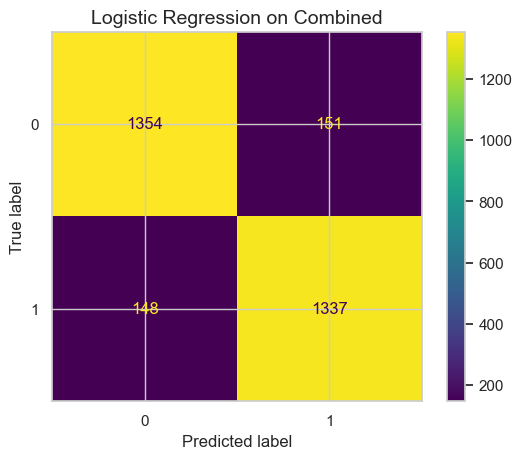

In [ ]:
# Confusion matrix for the best model
cm = confusion_matrix(y_test, best_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f'{best_model_name} on {best_feature_set}')
plt.show()

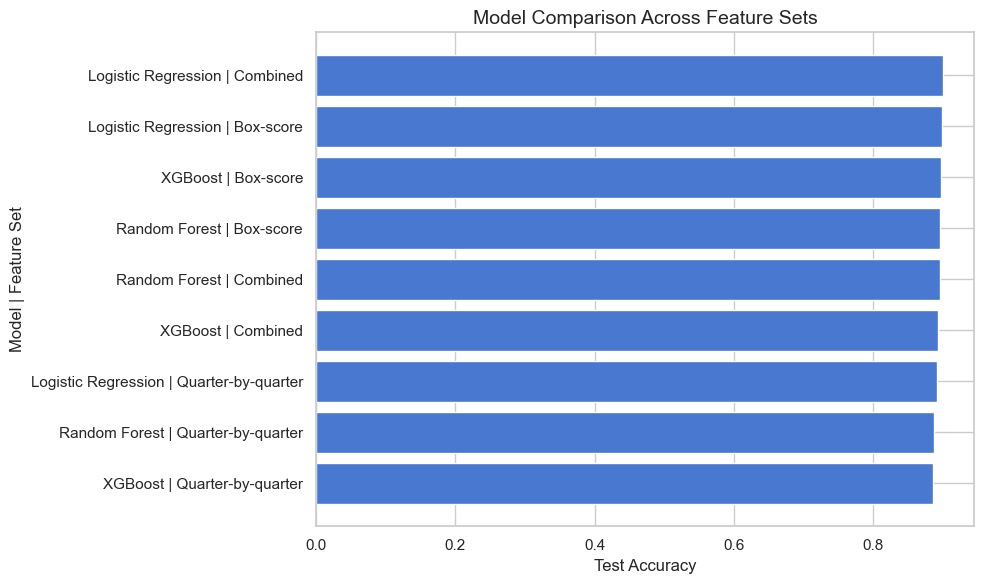

In [ ]:
# Model comparison box plot
plot_df = test_results_df.copy()
plot_df['Label'] = plot_df['Model'] + ' | ' + plot_df['Feature Set']
plot_df = plot_df.sort_values('Test Accuracy', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df['Label'], plot_df['Test Accuracy'])
plt.xlabel('Test Accuracy')
plt.ylabel('Model | Feature Set')
plt.title('Model Comparison Across Feature Sets')
plt.tight_layout()
plt.show()

**NOTE** The final report should not be overly long.  If this EDA step is huge and complicated  and you went down a lot of dead ends, then you should do something about that.  Some options... 

1) remove any EDA you later decided was unecessary side quest.
2) if the code to EDA is very long (in either lines or in time to compute) make sure you write out images of the EDA into `results/` and reload them as images here instead of recalculating it. And make a statement here like "To see the code responsible for EDA analyses see `02-EDACheckpoint.ipynb`."

## Analysis 1: Box-Score Efficiency Metrics Are the Strongest Individual Predictors

Our first major analysis examines whether team box-score variables differ meaningfully between games in which the favorite covered the spread and games in which it did not. Based on the earlier heatmap, we expect efficiency and margin-based statistics to be especially informative.

In [44]:
analysis1_table = stat_df[
    stat_df['Feature'].isin([
        'fav_FG_PCT',
        'fav_FG3_PCT',
        'fav_REB',
        'fav_TOV',
        'fav_PLUS_MINUS',
        'diff_FG_PCT',
        'diff_REB',
        'diff_TOV',
        'diff_PLUS_MINUS'
    ])
].copy()

analysis1_table

,Feature,Mean (Cover),Mean (No Cover),t-statistic,p-value,Cohen's d,r_pb
0,fav_FG_PCT,0.4957,0.4502,54.813,0.00e+00,0.897,0.4091
1,fav_FG3_PCT,0.3976,0.3343,42.389,0.00e+00,0.694,0.3277
2,fav_REB,45.8607,42.9240,27.791,8.80e-166,0.455,0.2216
3,fav_TOV,13.7946,14.2673,-7.495,6.99e-14,-0.123,-0.0612
4,fav_PLUS_MINUS,15.5004,-4.0594,136.291,0.00e+00,2.229,0.7443
5,diff_FG_PCT,0.0671,-0.0196,87.895,0.00e+00,1.438,0.5837
6,diff_REB,4.9476,-1.4050,45.793,0.00e+00,0.749,0.3507
7,diff_TOV,-0.9609,0.1015,-12.888,8.37e-38,-0.211,-0.1048
8,diff_PLUS_MINUS,31.0008,-8.1188,136.291,0.00e+00,2.229,0.7443


The table confirms that box-score features provide the strongest standalone signal in the project. The most notable variables are `fav_PLUS_MINUS`, `diff_PLUS_MINUS`, and `diff_FG_PCT`, all of which show very large effect sizes and extremely small p-values. This means that favorites who cover are not just slightly better in these games — they are usually much better in overall margin control and shooting efficiency.

These findings are important because they align with the earlier correlation analysis, where plus-minus differential and field-goal percentage differential were the strongest linear associations with spread coverage. Rebounding and turnovers are still useful, but their smaller effect sizes suggest that they are more supportive than central predictors.

Overall, box-score efficiency metrics appear to be the strongest individual predictors of spread coverage. This gives us an early reason to expect the box-score and combined feature sets to perform especially well in the final model comparison.

## Analysis 2: Quarter-by-Quarter Scoring Patterns Add Useful Game-Flow Information

Our second major analysis focuses on intra-game scoring structure. These quarter-based features are designed to capture how favorites build or lose control over the course of the game, rather than only summarizing final aggregate performance.

In [ ]:
# Focused table for quarter-level features
analysis2_table = stat_df[
    stat_df['Feature'].isin([
        'fav_first_half_margin',
        'fav_second_half_margin',
        'fav_q3_swing'
    ])
].copy()

analysis2_table

,Feature,Mean (Cover),Mean (No Cover),t-statistic,p-value,Cohen's d,r_pb
9,fav_first_half_margin,8.2290,-1.4934,63.556,0.00e+00,1.040,0.4613
10,fav_second_half_margin,7.0838,-2.4886,64.315,0.00e+00,1.052,0.4655
11,fav_q3_swing,0.2375,-0.1691,2.125,3.36e-02,0.035,0.0174


The quarter-based results show that scoring patterns do contain meaningful predictive information. Both `fav_first_half_margin` and `fav_second_half_margin` show large and highly significant differences between cover and no-cover games, which suggests that favorites who cover tend to establish stronger margins throughout the game rather than only at the very end.

At the same time, not every quarter-level feature is equally useful. `fav_q3_swing` is statistically significant, but its effect size is very small compared with the half-margin variables. This suggests that broad scoring control across halves is more informative than isolated momentum shifts in a single quarter.

Overall, Quarter-by-quarter scoring variables clearly matter, but they seem to work best as complementary features rather than the strongest standalone predictors.

## Analysis 3: Model Comparison Across Feature Sets

To directly answer our research question, we compare Logistic Regression, Random Forest, and XGBoost across three feature sets: quarter-by-quarter scoring variables, box-score variables, and a combined feature set containing both. We first examine the cross-validated performance of each model-feature combination, then evaluate the tuned models on the held-out test set.

In [ ]:
cv_results_table_pct

Model,Feature Set,Logistic Regression,Random Forest,XGBoost
0,Box-score,89.60,89.35,89.51
1,Combined,89.51,89.57,89.51
2,Quarter-by-quarter,88.90,88.68,88.86


The cross-validation results show two clear patterns. First, models using the box-score and combined feature sets consistently outperform models using quarter-by-quarter features alone. Second, the top cross-validated performances are all very close to one another, which suggests that feature design may matter at least as much as model complexity in this task. In particular, the box-score and combined feature sets both cluster around the high 89% range in cross-validation, while the quarter-by-quarter-only models are lower, around the high 88% range. This indicates that quarter-level features are useful, but not as strong on their own as the more traditional efficiency and differential box-score variables.

In [58]:
test_results_pct
summary_table = test_results_pct.copy()
summary_table = summary_table.rename(columns={'Test Accuracy': 'Test Accuracy (%)'})
summary_table

,Feature Set,Model,Test Accuracy (%)
0,Combined,Logistic Regression,90.00
1,Box-score,Logistic Regression,89.83
2,Box-score,XGBoost,89.80
3,Box-score,Random Forest,89.67
4,Combined,Random Forest,89.60
5,Combined,XGBoost,89.40
6,Quarter-by-quarter,Logistic Regression,89.16
7,Quarter-by-quarter,Random Forest,88.80
8,Quarter-by-quarter,XGBoost,88.60


The held-out test results provide the clearest answer to our project question. The best overall model is **Logistic Regression on the combined feature set**, which achieves a test accuracy of **90.00%**. The next-best results come from the box-score feature set, where Logistic Regression, XGBoost, and Random Forest all perform just below 90%.

This suggests that the strongest core signal comes from box-score efficiency metrics, but that quarter-by-quarter scoring variables still add enough complementary information to push the combined feature set slightly higher. It also suggests that the relationships captured by these engineered features may be fairly stable and mostly linear, since Logistic Regression slightly outperforms the more flexible tree-based models.

In [59]:
print(classification_report(y_test, best_y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9015    0.8997    0.9006      1505
           1     0.8985    0.9003    0.8994      1485

    accuracy                         0.9000      2990
   macro avg     0.9000    0.9000    0.9000      2990
weighted avg     0.9000    0.9000    0.9000      2990



To better understand the quality of the winning model, we also examine its classification report and confusion matrix. The classification report shows balanced performance across both classes. Precision, recall, and F1-score are all about 0.90 for both favorites who covered and favorites who did not. This is significant because it means the model is not simply exploiting class imbalance or overpredicting one outcome. Instead, it performs consistently across both classes, which strengthens the credibility of the final result.

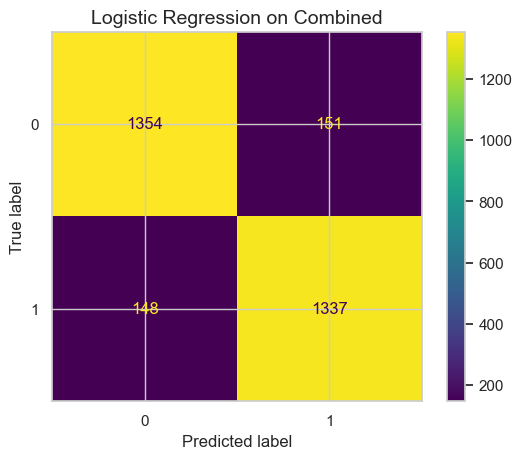

In [60]:
cm = confusion_matrix(y_test, best_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f'{best_model_name} on {best_feature_set}')
plt.show()

The confusion matrix reinforces the same conclusion. The errors are relatively balanced between false positives and false negatives, which is exactly what we want for a well-behaved binary classifier. Taken together, the classification report and confusion matrix suggest that the winning model is not only accurate overall, but also stable and balanced in how it handles both outcomes.

Taken together, the final modeling results support our original hypothesis. Box-score variables provide the strongest individual signal, and quarter-by-quarter scoring features improve performance when combined with them.

The three analyses tell a consistent story. The inferential results showed that box-score efficiency and plus-minus variables were the strongest individual predictors, while half-level scoring margins also carried meaningful signal. The modeling results reflected the same pattern: quarter-by-quarter features alone were competitive but weaker, box-score features were stronger, and the combined feature set achieved the best overall performance.

## Ethics


### A. Data Collection
 - [X] **X A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Not applicable. There are no individual human subjects involved in our data, it is simply public data that contains information regarding the outcome of NBA games.

 - [X] **X A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

 > Not applicable. Again, our dataset consists of publicly available game statistics and betting odds so there can't be any individual bias that skews the data.

 - [X] **X A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

 > The data consists of limited personal information. All the data is in reference to entire team performance. Individual player statistics or characteristics are not used in the dataset, only their names, and in this instance, they are already public figures/celebrities.

 - [X] **X A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

 > While the team-level data doesn't have any biases pertaining to race or gender, there can be other factors that contribute to skewed data. The models might perform differently for West Coast vs East Coast teams due to extra travel or time zone effects. There could also be bias involving small-market teams as these teams might not receive enough attention to warrant a betting line that is as accurate as it would be for a larger team.

### B. Data Storage
 - [X] **X B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> Data will be stored in our private GitHub repositories. Moreover, this data is all publicly available information that is free for use, there is nothing we need to explicitly protect.

 - [X] **X B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> Not applicable as there is no personal information involved in this dataset.

 - [X] **X B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> The data will be deleted following the completion of the COGS 108 course. This is simply because this is public data and there is no reason for us to store personal copies after the completion of this project.

### C. Analysis
 - [X] **X C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

 > As we are just students and not professional sports analysts, we will be addressing blindspots in the analysis by reviewing literature written by these professional analysts. 

 - [X] **X C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> We will create a plan for the creation of our models before ever starting on them so that we can avoid enforcing our personal biases on the model creation process.

 - [X] **X C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> Yes. Our visualizations will use appropriate scaling and labeling in order to show the data as accurately as possible.

 - [X] **X C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> There is no data with PII.

 - [X] **X C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> We will ensure that we document the process extensively before starting the project.

### D. Modeling
 - [X] **X D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

> The data is based on real-world outcomes of NBA games. There are no inherently unfair or discriminatory stats as they are simply reflections of what happened at these games. 

 - [X] **X D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

> The data is based on real-world outcomes of NBA games. There are no inherently unfair or discriminatory stats as they are simply reflections of what happened at these games. 

 - [X] **X D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

> We are considering finding more datasets to supplement our data regarding quarter-by-quarter scoring statistics.

 - [X] **X D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

> Yes, we will work to make our models as interpretable as possible.

 - [X] **X D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> Yes, we will work to make our models as interpretable as possible so we can accurately identify shortcomings and limitations.


### E. Deployment
 - [X] **X E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

> This is an academic project that won't be deployed.

 - [X] **X E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

> This is an academic project that won't reach the hands of consumers who could get hurt.

 - [X] **X E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

> This won't enter production.

 - [X] **X E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

> The model won't be used by anyone other than us.


## Discussion and Conclusion

This project set out to answer which type of basketball information is most useful for predicting whether NBA betting favorites cover the point spread, whether it's quarter-by-quarter scoring patterns, team box-score efficiency metrics, or a combination of both. Across our analyses, the clearest result is that the combined feature set performed best overall, with Logistic Regression achieving a held-out test accuracy of 90.0%. This supports our main hypothesis that quarter-based game-flow features and traditional box-score metrics provide complementary predictive value when used together.

More specifically, our inferential analysis showed that the strongest individual signals came from box-score differential features, especially plus-minus and field-goal percentage. These variables consistently showed the largest correlations with spread coverage and the largest effect sizes in the statistical tests. This suggests that favorites who cover are usually doing so through clearly stronger overall efficiency and point-margin control. At the same time, first-half and second-half scoring margins were also highly informative, which indicates that when and how teams build their leads matters in addition to their final box-score profile.

One interesting outcome of the project is that the best-performing model was Logistic Regression rather than Random Forest or XGBoost. Since tree-based models can capture more complex nonlinear structure, we initially expected one of them to dominate. Instead, the best performance came from the simpler linear model on the combined feature set. This suggests that the engineered features themselves already capture much of the useful signal in a stable and fairly linearly separable way.

These findings also help place our work in context relative to the prior literature. Earlier studies often focused on predicting outright game winners and found that team-level efficiency features were among the strongest predictors. Our project extends that literature by moving to the more difficult problem of spread coverage, where the betting market has already incorporated a large amount of public information into the line. The fact that our models still identify strong signal in box-score efficiency and game-flow variables suggests that these features remain meaningful even in a tougher prediction setting.

However, here are several limitations to our study. First, our analysis is restricted to the specific datasets we were able to merge, which reduced the final modeling sample to about 14,950 games. Second, our feature set focuses on within-game outcomes and same-game box-score statistics, which may limit how useful the model would be in a true pre-game forecasting setting. Finally, the betting market evolves over time, so relationships that hold across 2010–2024 may not remain equally strong in future seasons.

A possible next step would be to incorporate more explicitly pre-game information such as rest days, injuries, back-to-backs, travel, team form, or rolling averages from previous games. Another useful extension would be to evaluate additional metrics such as ROC-AUC or calibration error, and to test whether model performance changes over time across different NBA eras. It would also be valuable to examine whether the same findings hold for underdogs, playoff games, or alternative betting markets.

Overall, our project shows that both team efficiency and intra-game scoring structure matter for spread coverage, but that box-score metrics provide the strongest individual signal while quarter-by-quarter features improve performance when combined with them.
